# HR Analytics - Turnover Analysis (v2)

## Sobre o projeto
Uma empresa de consultoria que atua em Big Data e Data Science deseja contratar Cientistas de Dados entre pessoas que obtenham aprovação em alguns cursos ministrados pela empresa. A empresa quer saber quais desses candidatos realmente querem trabalhar para a empresa após o treinamento ou estão apenas fazendo o treinamento para retornarem ao mercado à procura de um novo emprego.

Nosso objetivo é realizar um extenso trabalho de análise nos dados, compreender como estão organizados, realizar limpeza e transformação conforme necessário, detectar padrões e ao final emitir um parecer com um resumo sobre os dados.

## O que mudou na v2
- Código refatorado em **funções reutilizáveis** nos módulos `src/etl.py` e `src/eda.py`
- **Pipeline de ETL separado da análise** (uma única chamada executa toda a limpeza)
- Notebook reorganizado em seções claras: Carga → EDA → ETL → Verificação → Relatório
- Correção de bug da v1: a imputação de `major_discipline` sobrescrevia linhas inteiras com 'Other' em vez de apenas a coluna

## Fonte de dados
Dataset disponível em: https://www.kaggle.com/arashnic/hr-analytics-job-change-of-data-scientists

Este conjunto de dados foi desenvolvido para entender os fatores que levam uma pessoa a deixar o emprego atual.

In [1]:
# Imports
import pandas as pd

# Módulos do projeto: pipeline de ETL e funções de EDA
from src import etl, eda

# Ignore warnings
import sys
import warnings
if not sys.warnoptions:
    warnings.simplefilter('ignore')

## 1. Carga dos dados brutos

In [2]:
df = etl.carregar_dados('dataset/aug_train.csv')
df.shape

(19158, 14)

In [3]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

## 2. Análise Exploratória de Dados (EDA)

In [5]:
# Resumo estatístico dos dados não numéricos
df.describe(include=object)

,city,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job
count,19158,14650,19158,18772,18698,16345,19093,13220,13018,18735
unique,123,3,2,3,5,6,22,8,6,6
top,city_103,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,50-99,Pvt Ltd,1
freq,4355,13221,13792,13817,11598,14492,3286,3083,9817,8040


In [6]:
# Resumo estatístico dos dados numéricos
# enrollee_id é apenas identificação e target é categórica, então ficam fora
df.describe().drop(columns=['enrollee_id', 'target'])

,city_development_index,training_hours
count,19158.000000,19158.000000
mean,0.828848,65.366896
std,0.123362,60.058462
min,0.448000,1.000000
25%,0.740000,23.000000
50%,0.903000,47.000000
75%,0.920000,88.000000
max,0.949000,336.000000


* Em **city_development_index** (CDI), os valores médios são 0,828, mediana 0,903 e std 0,123. Isso significa que a maioria dos candidatos é de cidades bem desenvolvidas.
* Em **training_hours**, os valores médios são 65,367, mediana 47 e max 336. Isso significa que há mais candidatos com poucas horas de treinamento, mas alguns candidatos gastam muito tempo para fazer o treinamento.

### 2.1 Variáveis categóricas

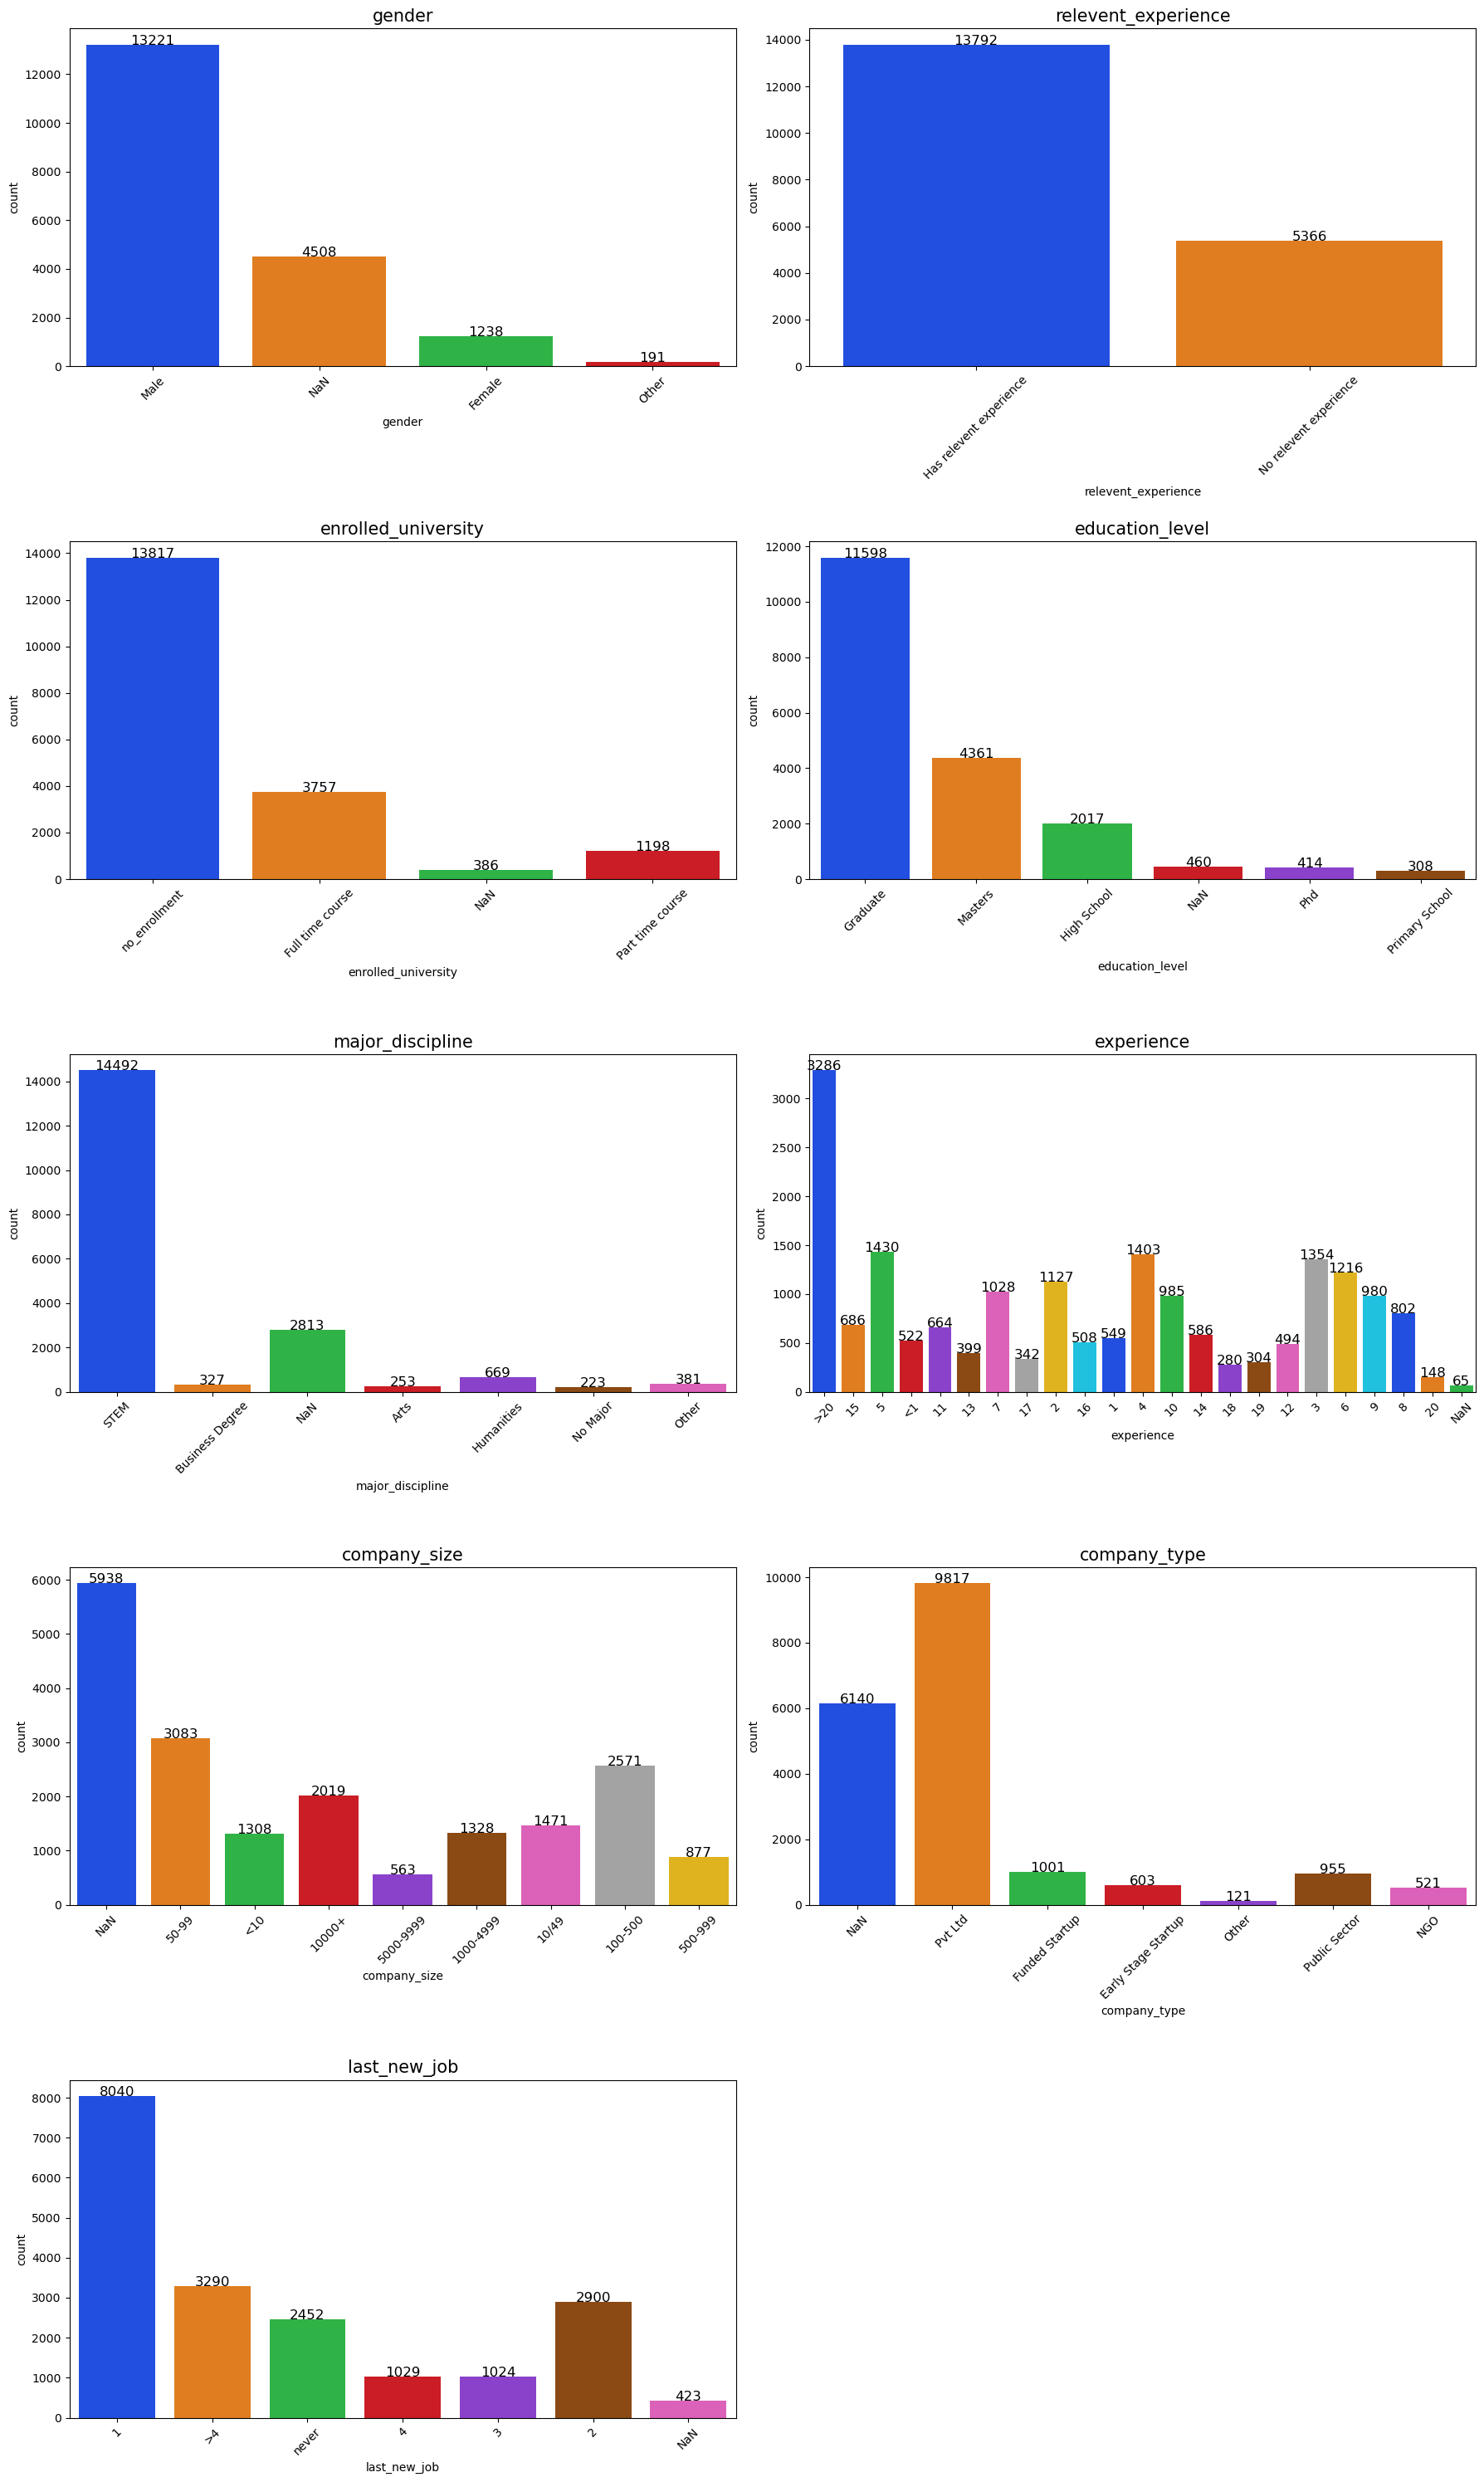

In [7]:
# Countplot de todas as variáveis categóricas (NaN aparece como categoria)
colunas_categoricas = list(df.columns.values)[3:12]
eda.plotar_categoricas(df, colunas_categoricas)

### 2.2 Distribuição das variáveis numéricas

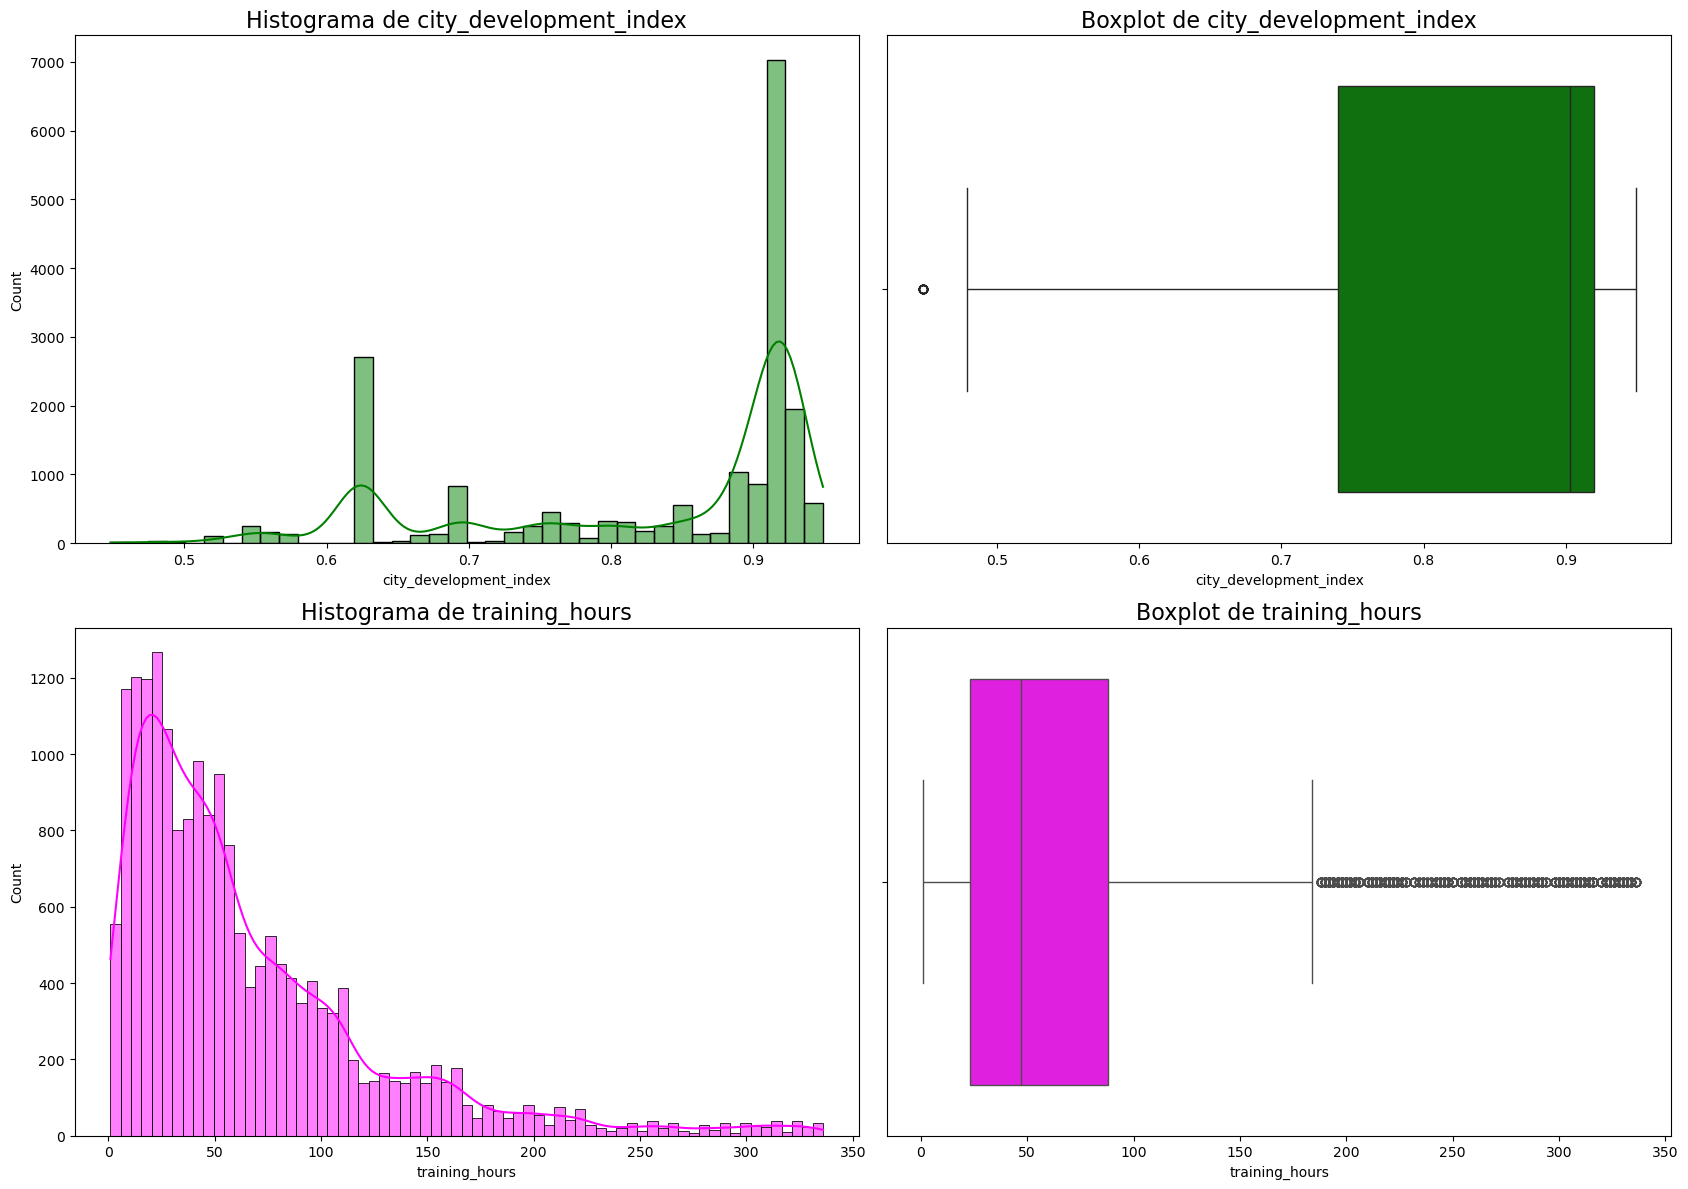

In [8]:
colunas_numericas = ['city_development_index', 'training_hours']
eda.plotar_distribuicao(df, colunas_numericas)

In [9]:
# Teste de normalidade (D'Agostino-Pearson)
eda.testar_normalidade(df, colunas_numericas)

city_development_index : Distribuição Não Normal
training_hours : Distribuição Não Normal


{'city_development_index': False, 'training_hours': False}

* As variáveis **city_development_index** e **training_hours** não seguem a distribuição normal — os boxplots também mostram presença de outliers. Para a análise numérica, usaremos o método não paramétrico (Spearman).
* Dados de **training_hours** estão localizados principalmente no lado esquerdo do histograma. É um comportamento esperado porque as pessoas geralmente ficam animadas ao fazer o treinamento no início, mas nem todos que começam conseguem terminar uma maratona. ;-)

### 2.3 Correlação de Spearman entre variáveis numéricas

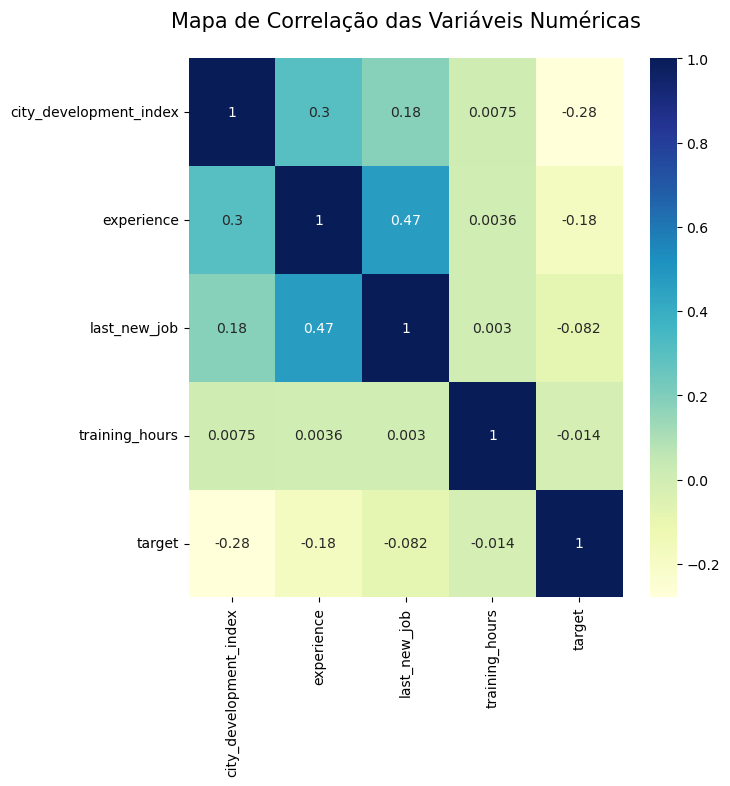

,city_development_index,experience,last_new_job,training_hours,target
city_development_index,1.000000,0.300997,0.182698,0.007491,-0.279165
experience,0.300997,1.000000,0.473284,0.003569,-0.183721
last_new_job,0.182698,0.473284,1.000000,0.002959,-0.082045
training_hours,0.007491,0.003569,0.002959,1.000000,-0.014126
target,-0.279165,-0.183721,-0.082045,-0.014126,1.000000


In [10]:
# Converte experience e last_new_job para numéricas (em uma cópia, sem alterar o df original)
df_numerical = etl.converter_variaveis_numericas(df)
corr = eda.plotar_correlacao_spearman(df_numerical)
corr

Pela correlação de Spearman, `last_new_job` e `experience` têm correlação média (0,473), enquanto as outras têm correlação fraca.

As variáveis `last_new_job` e `training_hours` têm correlação próxima de zero com a variável alvo e poderiam ser descartadas.

Para a relação entre as variáveis categóricas e a variável alvo, usaremos WOE e IV.

### 2.4 Weight of Evidence (WOE) e Information Value (IV)

Interpretação do IV:

| Information Value | Poder de previsão |
|---|---|
| < 0.02 | não deve ser usado para previsão |
| 0.02 - 0.1 | preditor fraco |
| 0.1 - 0.3 | preditor médio |
| 0.3 - 0.5 | preditor forte |
| > 0.5 | parece bom demais para ser verdade |

In [11]:
# Variáveis categóricas nominais usadas no cálculo do WOE/IV
colunas_cat = df.drop(columns=['target',
                               'enrollee_id',
                               'city',
                               'city_development_index',
                               'training_hours',
                               'experience',
                               'last_new_job',
                               'company_size']).columns

# WOE detalhado por variável
for col in colunas_cat:
    print(eda.calcular_woe_iv(df, col),
          '\n------------------------------------------------------------')

target      0.0       1.0       woe        iv
gender                                       
Female  0.08098  0.096222  0.172452  0.003337
Male    0.90650  0.889020 -0.019471  0.003337
Other   0.01252  0.014758  0.164458  0.003337 
------------------------------------------------------------
target                        0.0       1.0       woe        iv
relevent_experience                                            
Has relevent experience  0.753147  0.619845 -0.194790  0.083523
No relevent experience   0.246853  0.380155  0.431784  0.083523 
------------------------------------------------------------
target                    0.0       1.0       woe        iv
enrolled_university                                        
Full time course     0.164754  0.307477  0.623947  0.118886
Part time course     0.063465  0.064890  0.022210  0.118886
no_enrollment        0.771781  0.627632 -0.206746  0.118886 
------------------------------------------------------------
target                0.0   

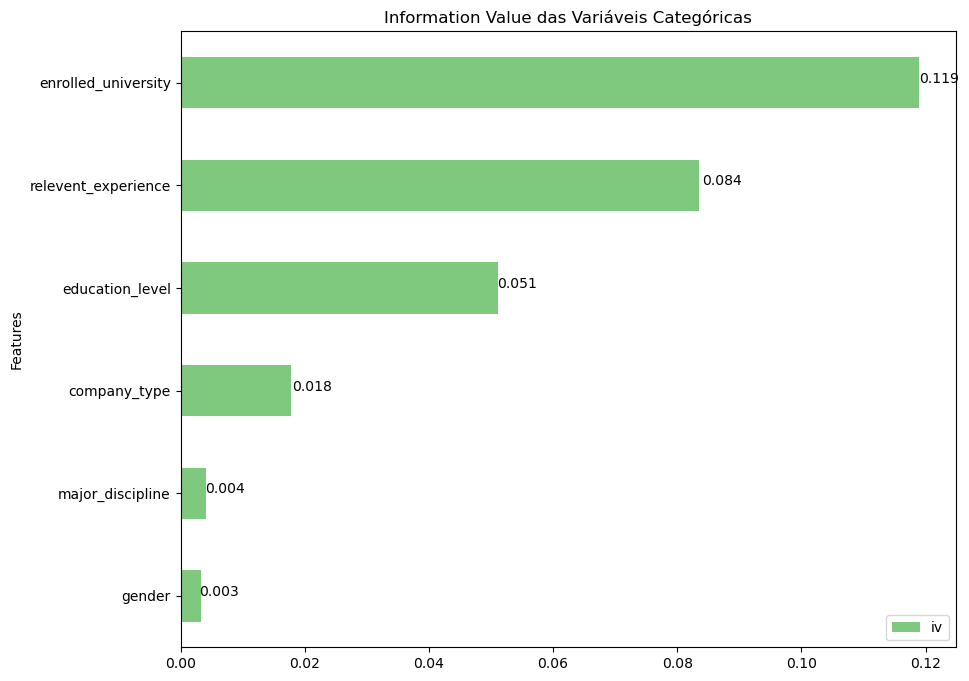

,iv
Features,
gender,0.003337
major_discipline,0.004148
company_type,0.017772
education_level,0.051170
relevent_experience,0.083523
enrolled_university,0.118886


In [12]:
# IV consolidado e plot
df_iv = eda.calcular_iv_features(df, colunas_cat)
eda.plotar_iv(df_iv)
df_iv

* No gráfico acima, podemos ver a ordem dos recursos com base em seu poder preditivo em relação ao alvo.
* Com base em seu valor IV, `enrolled_university` é um preditor médio, `relevent_experience` e `education_level` são preditores fracos e os outros são inúteis para a previsão.

### 2.5 Valores ausentes

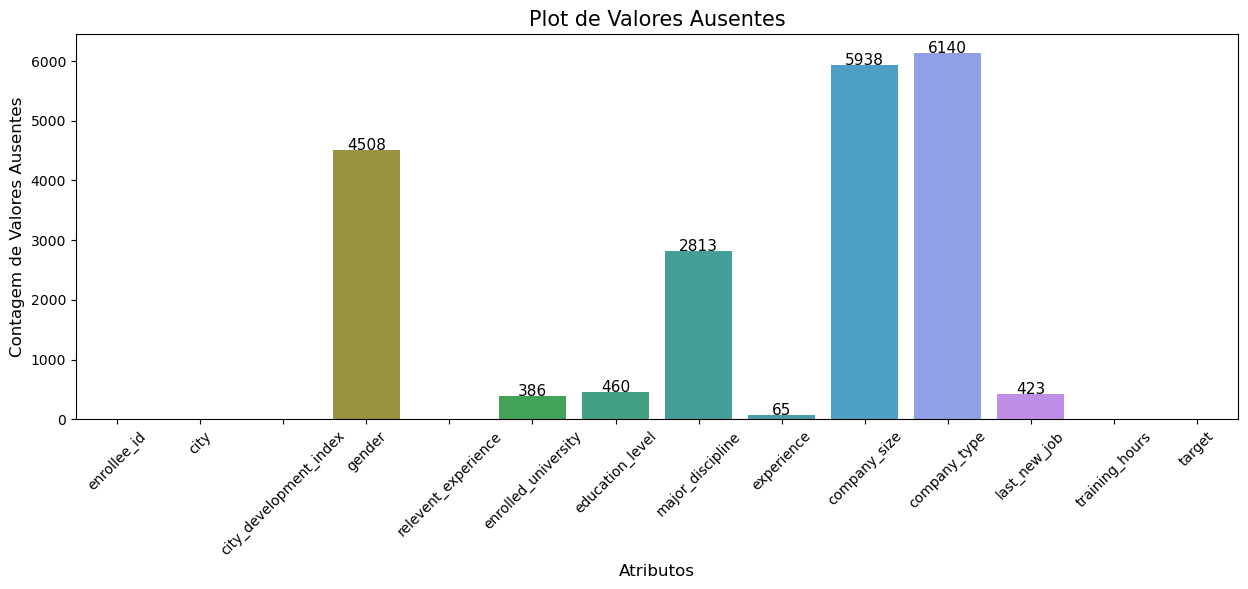

In [13]:
eda.plotar_valores_ausentes(df)

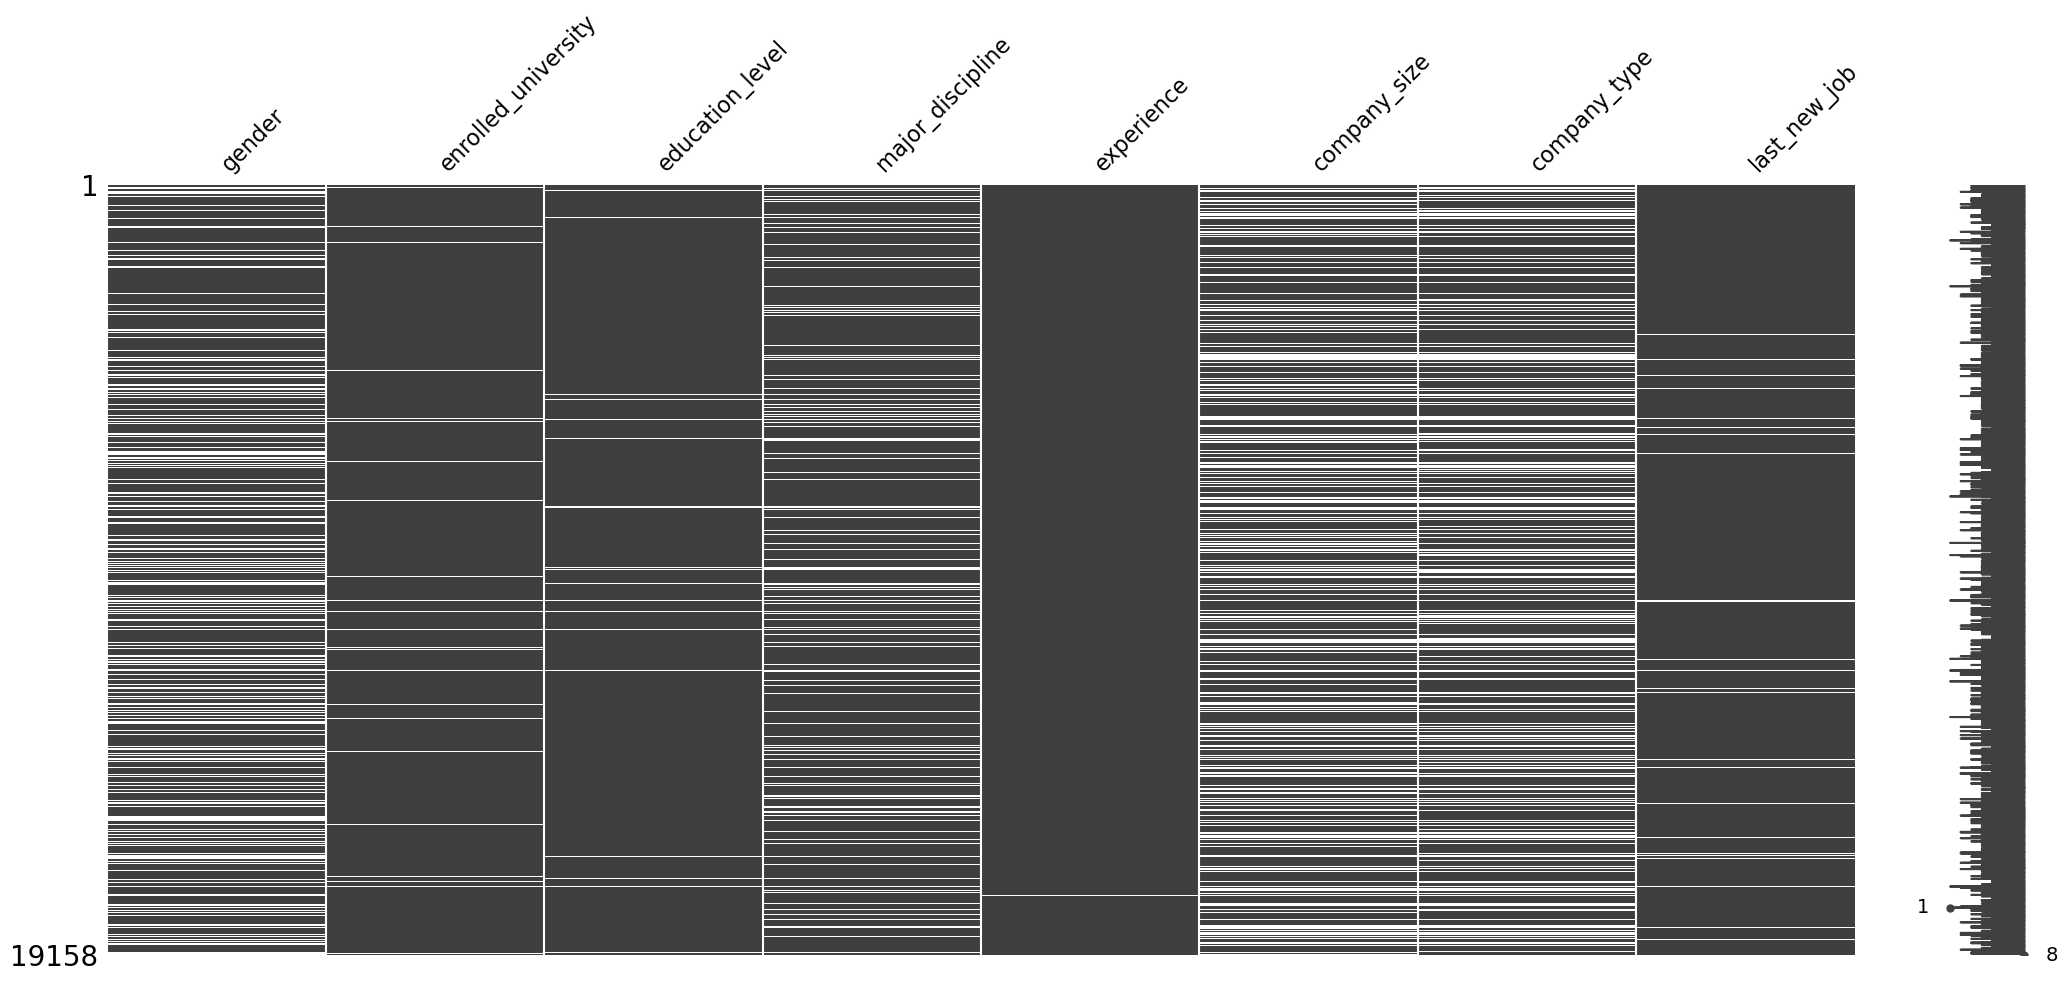

In [14]:
# Mapa de valores ausentes (apenas colunas com ausência)
eda.plotar_mapa_ausentes(df)

Com o gráfico dos valores ausentes, percebe-se que não existe padrão para a ausência — são aleatórias.

In [15]:
# Verificando duplicidade
df['enrollee_id'].duplicated().sum()

0

### 2.6 Balanceamento da variável alvo

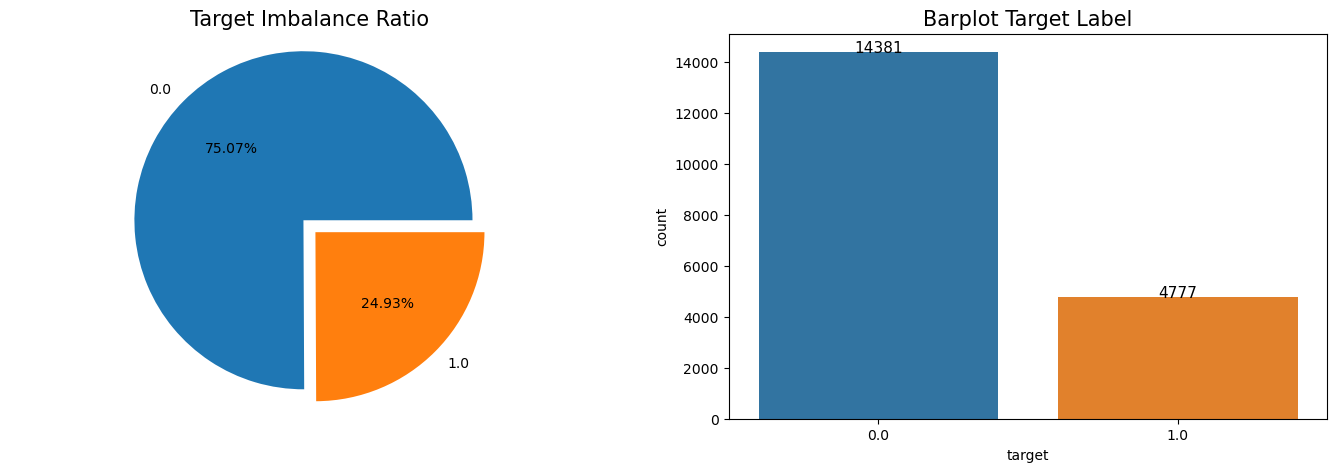

In [16]:
eda.plotar_balanceamento_target(df)

Os dados estão desbalanceados em relação à variável target — ponto importante para a futura etapa de modelagem preditiva.

## 3. Pipeline de ETL

Toda a limpeza está encapsulada em `src/etl.py`. Regras de negócio aplicadas:

1. **Seleção de colunas**: mantém apenas as variáveis relevantes identificadas na EDA (`etl.COLUNAS_MANTER`)
2. **major_discipline**: candidatos sem graduação (High School, Primary School ou ausente) recebem `Non Degree`; o restante dos ausentes recebe `Other`
3. **enrolled_university**: candidatos com `Primary School` recebem `Primary Grad` (não estão qualificados para a universidade); o restante recebe `Other`; padroniza `no_enrollment` → `No enrollment`
4. **company_type** e **education_level**: ausentes recebem `Other` (sem critério na documentação)
5. **experience**: percentual de ausentes irrisório → linhas removidas

In [17]:
# Executa o pipeline completo e grava o dataset limpo
df_limpo = etl.pipeline_etl('dataset/aug_train.csv', 'dataset/rh_candidatos_limpo.csv')
df_limpo.shape

(19093, 8)

In [18]:
df_limpo.head()

,city_development_index,experience,enrolled_university,relevent_experience,education_level,company_type,major_discipline,target
0,0.920,>20,No enrollment,Has relevent experience,Graduate,Other,STEM,1.0
1,0.776,15,No enrollment,No relevent experience,Graduate,Pvt Ltd,STEM,0.0
2,0.624,5,Full time course,No relevent experience,Graduate,Other,STEM,0.0
3,0.789,<1,Other,No relevent experience,Graduate,Pvt Ltd,Business Degree,1.0
4,0.767,>20,No enrollment,Has relevent experience,Masters,Funded Startup,STEM,0.0


### 3.1 Verificação pós-ETL

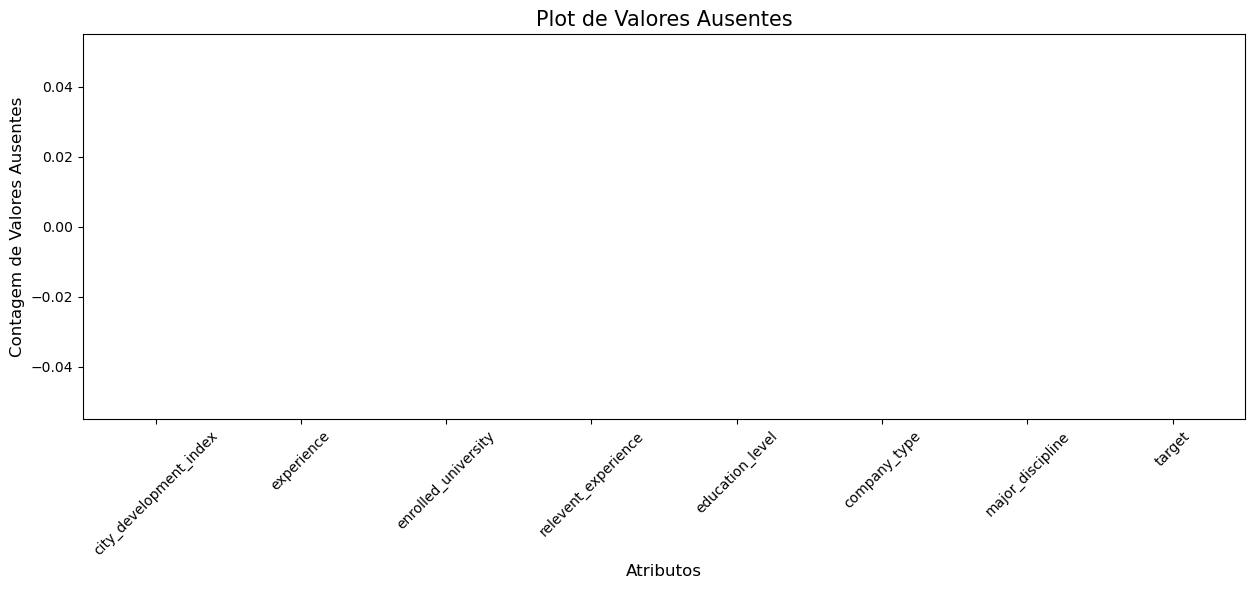

city_development_index    0
experience                0
enrolled_university       0
relevent_experience       0
education_level           0
company_type              0
major_discipline          0
target                    0
dtype: int64

In [19]:
# Confirma que não restou nenhum valor ausente
eda.plotar_valores_ausentes(df_limpo)
df_limpo.isna().sum()

In [20]:
# Categorias finais após a imputação
for col in ['major_discipline', 'enrolled_university', 'company_type', 'education_level']:
    print(df_limpo[col].value_counts(), '\n')

major_discipline
STEM               14451
Non Degree          2770
Humanities           668
Other                403
Business Degree      326
Arts                 252
No Major             223
Name: count, dtype: int64 

enrolled_university
No enrollment       13778
Full time course     3737
Part time course     1197
Other                 372
Primary Grad            9
Name: count, dtype: int64 

company_type
Pvt Ltd                9796
Other                  6225
Funded Startup          999
Public Sector           953
Early Stage Startup     601
NGO                     519
Name: count, dtype: int64 

education_level
Graduate          11566
Masters            4346
High School        2013
Other               450
Phd                 411
Primary School      307
Name: count, dtype: int64 



## 4. Relatório Final

Com base em nossa análise observamos que as variáveis mais relevantes para identificar um bom candidato são:

- Índice de Desenvolvimento da cidade onde mora o candidato.
- Tempo de experiência profissional.
- Se está ou não matriculado em um curso universitário.
- Se tem ou não experiência relevante.
- O nível educacional.
- O tipo de empresa que o candidato trabalhou ou trabalha atualmente.
- A especialização na graduação (quando for o caso).

Não são relevantes para a análise:

- O ID do candidato.
- O código da cidade do candidato.
- O gênero.
- A última vez que o candidato esteve empregado.
- O tamanho da empresa (quando for o caso).
- Total de horas de treinamento.

**Recomendações do Analista de Dados**:

- O RH pode desenvolver um método de coleta de dados para obter outros recursos a fim de melhorar a qualidade dos dados e tornar o trabalho de análise mais preciso.
- O RH pode procurar candidatos que vêm de cidades com índice de desenvolvimento urbano mais baixo, sem experiência relevante, nível de educação superior e menor experiência de trabalho para ter maior chance de encontrar candidatos que estão procurando um emprego.
- O RH pode tornar o treinamento mais compacto porque muitas pessoas não precisam de muito tempo para concluir o treinamento.

**Próximos passos (v3)**:

- Aprofundar análise orientada a negócio
- Evoluir para um modelo preditivo de turnover (atenção ao desbalanceamento do target)